### **项目 用逻辑回归预测游戏流失**

#### 分析目标 

#### 此次分析的目标是建立逻辑回归模型，基于玩家的年龄、性别、游戏类型、游戏时长、付费行为、会话频率、平均会话时长、等级、成就数、游戏难度等特征，预测玩家是否属于低参与度（可能流失） 群体。模型将帮助识别高风险流失玩家，为运营策略提供依据。

##### `online_gaming_behavior_dataset.csv`每列的含义如下

- PlayerID：玩家ID（从9000~40033）
- Age：玩家年龄（从15~49岁）
- Gender：玩家性别（男或女）
- Location：玩家地址
- GameGenre：游戏类型（5种）
- PlayTimeHours：游玩时间(小时)
- InGamePurchases：游戏内购买
   - 0  消费
   - 1  未消费
- GameDifficulty：游戏难度（低、中、高难度）
- SessionsPerWeek：每周的会话次数
- AvgSessionDurationMinutes：平均会话时长(分钟)
- PlayerLevel：玩家等级（1~99级）
- AchievementsUnlocked：已解锁成就（0~49个）
- EngagementLevel：参与度（低、中、高参与度）

数据来源于kaggle，包含40034条玩家数据

### **读取数据**

In [1]:
import numpy as np
import pandas as pd

In [2]:
original_data = pd.read_csv('online_gaming_behavior_dataset.csv')
original_data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


### **评估和清洗数据**

In [3]:
cleaned_data = original_data.copy()
cleaned_data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


#### **整齐度**

In [4]:
cleaned_data.head(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.752716,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.401729,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.152733,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High


In [5]:
cleaned_data.tail(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
40024,49024,25,Male,Other,Action,19.734643,0,Easy,3,87,61,44,Medium
40025,49025,47,Female,USA,Simulation,3.654450,0,Easy,5,137,82,20,Medium
40026,49026,33,Male,Other,Sports,19.825140,1,Easy,12,166,44,11,High
40027,49027,17,Male,Europe,Simulation,1.273467,0,Easy,6,24,52,17,Low
40028,49028,36,Male,USA,RPG,1.020489,0,Hard,4,34,97,21,Low
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium
40033,49033,19,Male,USA,Sports,10.083804,0,Easy,13,84,72,39,Medium


In [6]:
cleaned_data.sample(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
365,9365,46,Male,USA,RPG,15.378451,0,Medium,1,145,5,4,Low
39315,48315,49,Male,Europe,Strategy,23.539909,0,Easy,8,140,4,49,Medium
29323,38323,16,Male,Europe,Action,0.757833,1,Easy,16,31,23,20,Medium
37838,46838,18,Male,Europe,Simulation,0.236717,0,Easy,12,110,97,4,Medium
22780,31780,45,Female,Europe,Simulation,0.011623,0,Medium,15,73,92,37,Low
14596,23596,39,Male,Asia,Strategy,15.319385,0,Medium,6,18,13,12,Low
18494,27494,42,Male,Asia,Strategy,14.614050,0,Easy,4,164,36,0,Medium
20571,29571,49,Female,Europe,Action,10.557956,0,Medium,12,139,11,27,High
11410,20410,49,Male,USA,Action,7.120730,0,Easy,12,62,28,2,Medium
10259,19259,46,Male,USA,Strategy,21.275720,0,Easy,2,23,64,19,Low


##### 从头部的10行数据、结尾的10行数据以及随机抽样的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

#### **干净度**

In [7]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  str    
 3   Location                   40034 non-null  str    
 4   GameGenre                  40034 non-null  str    
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  str    
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  str    
dtypes: float64(1), int64(7), str(5)
memory usage: 4.0 MB


##### 从何结果看来，每一个字段都不存在缺失行，但是PlayerID的数值类型应改为str，Gender、GameGenre、InGamePurchases、GameDifficulty、EngagementLevel的数值类型应改为category，

In [8]:
cleaned_data['PlayerID'] = cleaned_data['PlayerID'].astype('str')
cleaned_data['Gender'] = cleaned_data['Gender'].astype('category')
cleaned_data['GameGenre'] = cleaned_data['GameGenre'].astype('category')
cleaned_data['InGamePurchases'] = cleaned_data['InGamePurchases'].astype('category')
cleaned_data['GameDifficulty'] = cleaned_data['GameDifficulty'].astype('category')
cleaned_data['EngagementLevel'] = cleaned_data['EngagementLevel'].astype('category')

##### 检查更改后的结果

In [9]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   PlayerID                   40034 non-null  str     
 1   Age                        40034 non-null  int64   
 2   Gender                     40034 non-null  category
 3   Location                   40034 non-null  str     
 4   GameGenre                  40034 non-null  category
 5   PlayTimeHours              40034 non-null  float64 
 6   InGamePurchases            40034 non-null  category
 7   GameDifficulty             40034 non-null  category
 8   SessionsPerWeek            40034 non-null  int64   
 9   AvgSessionDurationMinutes  40034 non-null  int64   
 10  PlayerLevel                40034 non-null  int64   
 11  AchievementsUnlocked       40034 non-null  int64   
 12  EngagementLevel            40034 non-null  category
dtypes: category(5), float64(1), int64(5), str(

##### 数值类型转换完成

#### **缺失值**

##### 无缺数值，无需处理

#### **重复数据**

##### 玩家ID(PlayerID)不能重复，除此之外还要检查存不存在整行重复的情况

In [10]:
cleaned_data.query('PlayerID.isna()')

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel


In [11]:
cleaned_data.duplicated().sum()

np.int64(0)

##### 从输出结果看来，PlayerID和整行均无重复数据

#### **不一致数据**

##### Gender、GameGenre、InGamePurchases、GameDifficulty、EngagementLevel里可能存在不一致数据，需要检查一下

In [12]:
cleaned_data['Gender'].value_counts()

Gender
Male      23959
Female    16075
Name: count, dtype: int64

In [13]:
cleaned_data['GameGenre'].value_counts()

GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64

In [14]:
cleaned_data['InGamePurchases'].value_counts()

InGamePurchases
0    31993
1     8041
Name: count, dtype: int64

In [15]:
cleaned_data['GameDifficulty'].value_counts()

GameDifficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64

In [16]:
cleaned_data['EngagementLevel'].value_counts()

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

##### 从输出结果看来，这几项均无不一致数据

#### **无效或错误数据**

In [17]:
cleaned_data.describe()

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,31.992531,12.024365,9.471774,94.792252,49.655568,24.526477
std,10.043227,6.914638,5.763667,49.011375,28.588379,14.430726
min,15.000000,0.000115,0.000000,10.000000,1.000000,0.000000
25%,23.000000,6.067501,4.000000,52.000000,25.000000,12.000000
50%,32.000000,12.008002,9.000000,95.000000,49.000000,25.000000
75%,41.000000,17.963831,14.000000,137.000000,74.000000,37.000000
max,49.000000,23.999592,19.000000,179.000000,99.000000,49.000000


##### 从输出结果看来，无脱离实际意义的数据存在

### **可视化探索与假设检验**

#### 先引入做t检验、z检验所需要的模块

In [18]:
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest

#### 再引入绘图所需要的模块

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

#### **分析付费行为与活跃的关系**

##### **将付费玩家与未付费玩家分开**

In [20]:
payplayer = cleaned_data.query("InGamePurchases == 1")
payplayer

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
11,9011,36,Female,Asia,Simulation,5.535981,1,Easy,16,124,62,31,High
12,9012,16,Male,USA,Sports,18.776234,1,Easy,9,18,52,32,High
31,9031,39,Male,USA,Sports,3.374946,1,Easy,5,70,50,11,Medium
40,9040,49,Female,Europe,Strategy,13.714087,1,Medium,15,43,93,29,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,49020,16,Male,USA,RPG,10.687862,1,Easy,16,118,18,16,High
40021,49021,43,Male,Asia,Action,6.146619,1,Medium,7,107,86,26,Medium
40026,49026,33,Male,Other,Sports,19.825140,1,Easy,12,166,44,11,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High


In [21]:
len(payplayer)

8041

In [22]:
unpayplayer = cleaned_data.query("InGamePurchases == 0")
unpayplayer

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40027,49027,17,Male,Europe,Simulation,1.273467,0,Easy,6,24,52,17,Low
40028,49028,36,Male,USA,RPG,1.020489,0,Hard,4,34,97,21,Low
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High


In [23]:
len(unpayplayer)

31993

##### **设置色盘与画布大小**

In [24]:
sns.set_palette("Set2")
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='InGamePurchases', ylabel='SessionsPerWeek'>

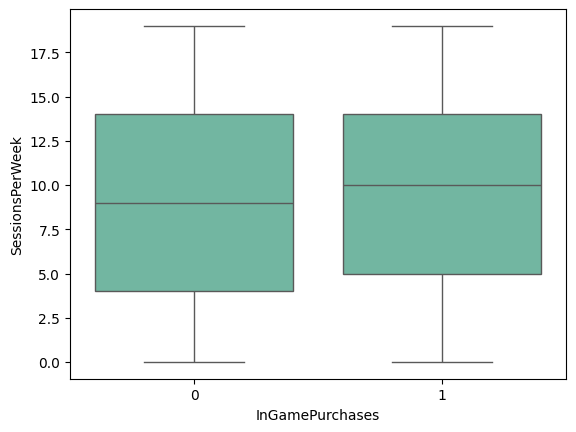

In [25]:
sns.boxplot(x = cleaned_data['InGamePurchases'],y = cleaned_data['SessionsPerWeek'])

从结果可以看出，没有付费行为的玩家与有付费行为的在平均会话时长(留存/活跃度)方面无显著差异，为了正是这个观点，我们需要通过统计学方法来验证

##### **建立假设1**

原假设$H_0$：没有付费行为的玩家与有付费行为的玩家其留存/活跃度无显著差异

备择假设$H_1$：没有付费行为的玩家与有付费行为的玩家其留存/活跃度有显著差异

##### **确认检验是单尾还是双尾**

我们只想确定付费玩家与未付费玩家的留存/活跃度存不存在显著差异，因此是双尾检验

##### **确定显著水平**

选择0.05作为显著水平

##### **计算z值和p值**

In [26]:
z_stat,p_value = ztest(unpayplayer['SessionsPerWeek'],payplayer['SessionsPerWeek'],alternative = 'two-sided')

In [27]:
print(f"z值为：{z_stat}")
print(f"p值为:{p_value}")

z值为：-1.0269229660705548
p值为:0.3044567391137627


##### **结论**

##### 由于p值大于显著水平0.05，我们因此拒绝备择假设，说明没有付费行为的玩家与有付费行为的玩家其留存/活跃度无显著差异

#### **分析参与度高低与游戏时长的关系**

##### **将高参与度玩家与低参与度玩家分开**

In [28]:
high_engagement_player = cleaned_data.query("EngagementLevel == 'High'")
high_engagement_player

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High
10,9010,17,Male,USA,Strategy,4.829916,0,Hard,8,95,14,12,High
11,9011,36,Female,Asia,Simulation,5.535981,1,Easy,16,124,62,31,High
12,9012,16,Male,USA,Sports,18.776234,1,Easy,9,18,52,32,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40013,49013,49,Female,USA,Strategy,9.077397,1,Medium,17,90,1,32,High
40020,49020,16,Male,USA,RPG,10.687862,1,Easy,16,118,18,16,High
40026,49026,33,Male,Other,Sports,19.825140,1,Easy,12,166,44,11,High
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High


In [29]:
len(high_engagement_player)

10336

In [30]:
low_engagement_player = cleaned_data.query("EngagementLevel == 'Low'")
low_engagement_player

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.752716,0,Hard,1,50,13,2,Low
13,9013,38,Female,USA,Strategy,8.701959,0,Easy,0,156,33,47,Low
14,9014,44,Male,USA,Simulation,17.975200,0,Easy,8,41,98,1,Low
17,9017,47,Male,USA,RPG,17.272113,0,Medium,2,131,13,9,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40018,49018,45,Male,Europe,Simulation,5.950284,0,Easy,7,38,56,12,Low
40022,49022,44,Male,Other,RPG,9.085086,0,Medium,3,31,69,43,Low
40023,49023,36,Male,USA,Simulation,2.529218,0,Medium,0,73,6,32,Low
40027,49027,17,Male,Europe,Simulation,1.273467,0,Easy,6,24,52,17,Low


In [31]:
len(low_engagement_player)

10324

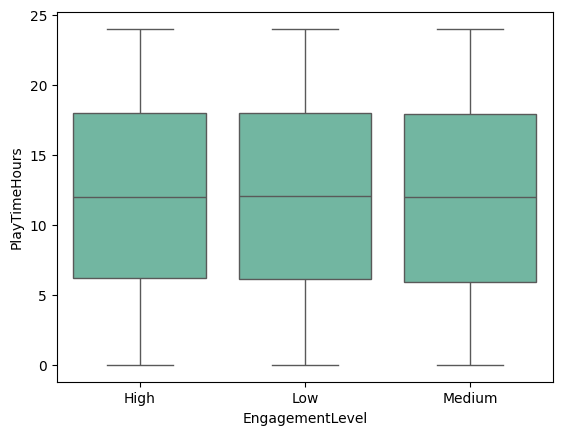

In [32]:
sns.boxplot(x = cleaned_data['EngagementLevel'],y = cleaned_data['PlayTimeHours'])
plt.show()

从结果可以看出，高参与度低参与度以及中等参与度玩家在游玩时长方面无显著差异，空口无凭，因此我们也需要通过统计学方法来验证

##### **建立假设2**

原假设$H_0$：高参与度玩家与低参与度玩家的平均游戏时长不存在显著差异

备择假设$H_1$：高参与度玩家与低参与度玩家的平均游戏时长存在显著差异

##### **确认检验是单尾还是双尾**

同理，此处是双尾

##### **确定显著水平**

选择0.05作为显著水平

##### **计算t值和p值**

In [33]:
t_stat, p_value = ttest_ind(high_engagement_player["PlayTimeHours"], low_engagement_player["PlayTimeHours"])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：-0.3715643967745735
p值：0.710221012114041


##### **结论**

##### 由于p值大于显著水平0.05，我们因此拒绝备择假设，说明高参与度玩家与低参与度玩家的平均游戏时长不存在显著差异

### **数据可视化探索**

#### **玩家年龄分布情况**

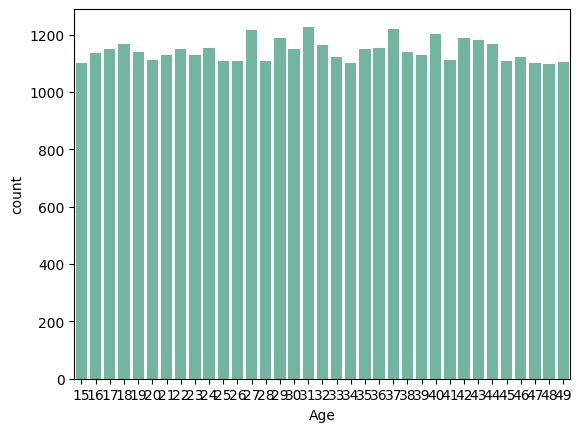

In [34]:
sns.countplot(cleaned_data,x = 'Age')
plt.show()

从结果可以看出，所有玩家的年龄分布十分均衡，不存在年龄越大或小就越不喜欢或喜欢玩游戏的现象

#### **各种类型的游戏占比**

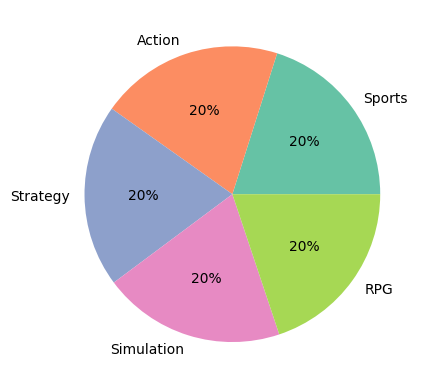

In [35]:
sort_GameGenre = cleaned_data["GameGenre"].value_counts()
plt.pie(sort_GameGenre, autopct='%.0f%%', labels=sort_GameGenre.index)
plt.show()

5种游戏的占比也十分均衡，各占20%

#### **玩家性别占比**

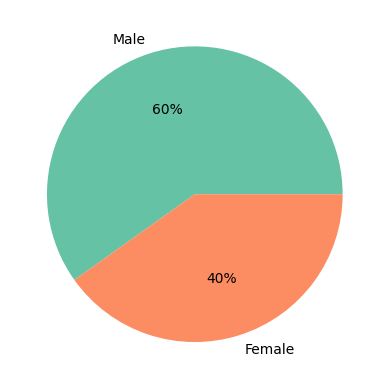

In [36]:
gender_count = cleaned_data['Gender'].value_counts()
plt.pie(gender_count, labels=gender_count.index, autopct='%.0f%%')
plt.show()

男性玩家的数量比女性玩家的数量多出10%，由此可以猜测性别可能是影响游戏活跃的的因素，但还不能下结论，需要后续验证

### **建立预测模型**

##### 引入做逻辑回归所需的模块

In [37]:
import statsmodels.api as sm

##### 为了避免清洗好的数据丢失，创建一个新的DataFrame作为建立逻辑回归模型所使用的数据 logic_data

In [38]:
logic_data = cleaned_data.copy()
logic_data.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


##### 移除大概率不会影响玩家活跃度的变量

In [39]:
logic_data = logic_data.drop(['PlayerID', 'Location'],axis = 1)
logic_data.head()

,Age,Gender,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Action,15.531945,0,Medium,2,131,95,37,Medium


##### 数据里还存在分类变量，无法直接建立逻辑回归模型。需要引入虚拟变量，也就是用0和1分别表示是否属于该类别。

In [40]:
logic_data = pd.get_dummies(logic_data, drop_first=True, columns=['GameGenre', 'Gender','GameDifficulty','EngagementLevel'], dtype=int)
logic_data.head()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Gender_Male,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_Low,EngagementLevel_Medium
0,43,16.271119,0,6,108,79,25,0,0,0,1,1,0,1,0,1
1,29,5.525961,0,5,144,11,10,0,0,0,1,0,0,1,0,1
2,22,8.223755,0,16,142,35,41,0,0,1,0,0,0,0,0,0
3,35,5.265351,1,9,85,57,47,0,0,0,0,1,0,0,0,1
4,33,15.531945,0,2,131,95,37,0,0,0,0,1,0,1,0,1


#### **划分自变量和因变量**

In [41]:
y = logic_data['EngagementLevel_Low']

把除EngagementLevel_Low之外的先纳入自变量，但需要查看它们之间的相关性。如果其中有些变量之间相关性很高，会导致共线性。

In [42]:
X = logic_data.drop(['EngagementLevel_Low'], axis=1)
X.corr()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Gender_Male,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_Medium
Age,1.000000,0.002462,-0.000186,0.008777,-0.002269,0.001353,-0.001100,-0.008900,0.009609,0.000075,0.001205,-0.002075,-0.001916,-0.001358,0.008638
PlayTimeHours,0.002462,1.000000,-0.006067,-0.003655,-0.001925,-0.005152,0.003913,-0.001170,-0.009115,-0.004065,0.004159,0.006514,0.001059,0.000939,-0.009364
InGamePurchases,-0.000186,-0.006067,1.000000,0.005132,-0.003059,0.006524,0.000098,-0.003312,0.001027,0.000859,0.011026,0.006198,-0.001160,0.004427,-0.002664
SessionsPerWeek,0.008777,-0.003655,0.005132,1.000000,-0.000620,0.003257,0.003187,-0.005698,-0.002714,0.002229,0.006068,-0.006491,0.002568,0.004138,0.013692
AvgSessionDurationMinutes,-0.002269,-0.001925,-0.003059,-0.000620,1.000000,0.001368,-0.002227,-0.010669,-0.000536,0.002598,0.008668,-0.003175,0.004335,-0.003522,-0.097525
PlayerLevel,0.001353,-0.005152,0.006524,0.003257,0.001368,1.000000,0.006343,-0.003866,-0.007161,0.004127,0.004286,0.006645,0.005529,0.000675,0.043044
AchievementsUnlocked,-0.001100,0.003913,0.000098,0.003187,-0.002227,0.006343,1.000000,-0.000284,0.000954,-0.004492,0.001873,0.003772,-0.011627,0.009656,0.046300
GameGenre_RPG,-0.008900,-0.001170,-0.003312,-0.005698,-0.010669,-0.003866,-0.000284,1.000000,-0.248468,-0.249730,-0.249031,-0.005365,0.012891,-0.003109,0.002345
GameGenre_Simulation,0.009609,-0.009115,0.001027,-0.002714,-0.000536,-0.007161,0.000954,-0.248468,1.000000,-0.250338,-0.249637,-0.001601,0.000807,-0.000554,-0.009042
GameGenre_Sports,0.000075,-0.004065,0.000859,0.002229,0.002598,0.004127,-0.004492,-0.249730,-0.250338,1.000000,-0.250906,-0.001457,-0.003559,0.003052,-0.000466


In [43]:
X.corr().abs() > 0.8

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Gender_Male,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_Medium
Age,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
PlayTimeHours,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
InGamePurchases,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
SessionsPerWeek,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
AvgSessionDurationMinutes,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
PlayerLevel,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
AchievementsUnlocked,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
GameGenre_RPG,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
GameGenre_Simulation,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
GameGenre_Sports,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


从结果可以看出，不存在相关性很高的变量

给模型的线性方程添加截距

In [44]:
X = sm.add_constant(X)

调用Logit函数，利用最大似然优化来得到逻辑回归模型的参数值，并输出总结信息。

In [45]:
model = sm.Logit(y, X).fit()
model.summary()

         Current function value: 0.116948
         Iterations: 35


D:\Python\Python安装路径\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     EngagementLevel_Low   No. Observations:                40034
Model:                           Logit   Df Residuals:                    40018
Method:                            MLE   Df Model:                           15
Date:                 Sun, 16 Aug 2026   Pseudo R-squ.:                  0.7951
Time:                         16:40:51   Log-Likelihood:                -4681.9
converged:                       False   LL-Null:                       -22853.
Covariance Type:             nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         7.4286      0.169     43.966      0.000       7.097       7.760
Age                           0.0006      0.003      0.203      0.839      -0.005       0.006
PlayTimeHours                 0.0019      0.004      0.483      0.629      -0.006       0.010
InGamePurchases              -0.0922      0.068     -1.348      0.178      -0.226       0.042
SessionsPerWeek              -0.3588      0.005    -72.178      0.000      -0.369      -0.349
AvgSessionDurationMinutes    -0.0335      0.001    -58.014      0.000      -0.035      -0.032
PlayerLevel                  -0.0070      0.001     -7.207      0.000      -0.009      -0.005
AchievementsUnlocked         -0.0126      0.002     -6.534      0.000      -0.016      -0.009
GameGenre_RPG                 0.0032      0.088      0.037      0.971      -0.169       0.175
GameGenre_Simulation         -0.0587      0.087     -0.674      0.501      -0.230       0.112
GameGenre_Sports              0.0748      0.087      0.862      0.389      -0.095       0.245
GameGenre_Strategy            0.0428      0.087      0.493      0.622      -0.128       0.213
Gender_Male                   0.0333      0.056      0.591      0.554      -0.077       0.144
GameDifficulty_Hard          -0.0849      0.073     -1.171      0.242      -0.227       0.057
GameDifficulty_Medium        -0.0290      0.064     -0.454      0.650      -0.154       0.096
EngagementLevel_Medium      -20.2895     87.404     -0.232      0.816    -191.598     151.019
=============================================================================================

Possibly complete quasi-separation: A fraction 0.48 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

##### 此处出现警告！本次建模的目标（因变量 y）是 预测玩家是否为低参与度（EngagementLevel_Low），也就是“是否存在流失风险”。如果将 EngagementLevel_Medium 也作为自变量（特征）放入模型，就会产生完全分离（Complete Separation） 现象，我们要预测的是“是否为低参与度”，那么其他参与度等级（Medium 和 High）的信息在特征侧都属于“未来信息”或“确定性信息”，必须从自变量中剔除。因此，我们只保留真正的行为特征（每周会话次数、游戏时长、等级、成就数）来建立预测模型，这样得到的逻辑回归结果才是科学且可解释的。

In [46]:
X = logic_data[['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']]
X = sm.add_constant(X)
model = sm.Logit(y,X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.327098
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     EngagementLevel_Low   No. Observations:                40034
Model:                           Logit   Df Residuals:                    40029
Method:                            MLE   Df Model:                            4
Date:                 Sun, 16 Aug 2026   Pseudo R-squ.:                  0.4270
Time:                         16:40:51   Log-Likelihood:                -13095.
converged:                        True   LL-Null:                       -22853.
Covariance Type:             nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         5.0197      0.070     71.519      0.000       4.882       5.157
SessionsPerWeek              -0.3563      0.004    -86.809      0.000      -0.364      -0.348
AvgSessionDurationMinutes    -0.0281      0.000    -71.316      0.000      -0.029      -0.027
PlayerLevel                  -0.0105      0.001    -18.977      0.000      -0.012      -0.009
AchievementsUnlocked         -0.0221      0.001    -20.187      0.000      -0.024      -0.020
=============================================================================================
"""

逻辑回归模型预测以下因素的增加（或存在）会降低玩家流失的概率：每周会话次数、平均会话时间、玩家等级、已解锁成就。

要理解各个各个自变量系数的实际含义，我们需要计算自然常数的次方。

In [47]:
# SessionsPerWeek
np.exp(-0.3563)

np.float64(0.7002625099672979)

以上结果说明，每周会话次数每增加1次，玩家流失风险概率降低30%左右。

In [48]:
# AvgSessionDurationMinutes
np.exp(-0.0281)

np.float64(0.9722911328263465)

以上结果说明，平均会话时长每增加1min，玩家流失风险概率降低2.8%左右。

In [49]:
# PlayerLevel
np.exp(-0.0105)

np.float64(0.9895549325678993)

以上结果说明，玩家等级每增加1级，玩家流失风险概率降低1.1%左右。

In [50]:
# AchievementsUnlocked
np.exp(-0.0221)

np.float64(0.9781424159187431)

以上结果说明，游戏成就每解锁一个，玩家流失风险概率降低2.2%左右。

#### 根据模型参数值，我们总结：

每周会话次数越多的玩家流失概率越低；

平均会话时长越多的玩家流失概率越低；

玩家等级越高的玩家流失概率越低；

已解锁成就越多的玩家流失概率更低。

这表明增强玩家的活跃度（提高会话频率、延长游戏时间）、提升等级和鼓励成就获取，是降低玩家流失的有效策略。

### **模型评估**

#### **引入用来评估模型的工具**

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

#### **将数据拆分为“训练集”和“测试集”**

##### 准备特征 X和标签 y

In [52]:
X_final = logic_data[['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']]
y_final = logic_data['EngagementLevel_Low']

#### **拆分：70% 的数据用于训练模型，30% 的数据用于考试**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=42)
print(f"训练集样本数：{len(X_train)}")
print(f"测试集样本数：{len(X_test)}")

训练集样本数：28023
测试集样本数：12011


#### **用训练集重新拟合（训练）模型**

#### 给训练集和测试集都加上截距列（常数项）

In [54]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

#### **用训练集重新训练模型**

In [55]:
final_model = sm.Logit(y_train, X_train_const).fit()
final_model.summary()

Optimization terminated successfully.
         Current function value: 0.326593
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     EngagementLevel_Low   No. Observations:                28023
Model:                           Logit   Df Residuals:                    28018
Method:                            MLE   Df Model:                            4
Date:                 Sun, 16 Aug 2026   Pseudo R-squ.:                  0.4289
Time:                         16:40:52   Log-Likelihood:                -9152.1
converged:                        True   LL-Null:                       -16026.
Covariance Type:             nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         5.0361      0.084     59.979      0.000       4.872       5.201
SessionsPerWeek              -0.3599      0.005    -72.782      0.000      -0.370      -0.350
AvgSessionDurationMinutes    -0.0279      0.000    -59.423      0.000      -0.029      -0.027
PlayerLevel                  -0.0107      0.001    -16.147      0.000      -0.012      -0.009
AchievementsUnlocked         -0.0219      0.001    -16.784      0.000      -0.024      -0.019
=============================================================================================
"""

### **在测试集上进行预测，并计算概率**

#### 预测测试集里的玩家流失的概率

In [56]:
y_pred_prob = final_model.predict(X_test_const)
y_pred_prob

34667    0.044294
22227    0.110944
24899    0.432865
35415    0.049854
21440    0.087248
           ...   
26873    0.052906
24797    0.827438
24023    0.185994
38472    0.700130
6373     0.048466
Length: 12011, dtype: float64

#### 设定阈值为 0.5：概率 >= 0.5 就判定为“会流失”（1），否则为“不会流失”（0）

In [57]:
y_pred = (y_pred_prob >= 0.5).astype(int)
y_pred

34667    0
22227    0
24899    0
35415    0
21440    0
        ..
26873    0
24797    1
24023    0
38472    1
6373     0
Length: 12011, dtype: int64

### **生成混淆矩阵**

#### 计算混淆矩阵

In [58]:
cm = confusion_matrix(y_test, y_pred)

#### 用 Pandas 做成表格

In [59]:
cm_df = pd.DataFrame(cm, 
                     index=['实际未流失', '实际流失'], 
                     columns=['预测未流失', '预测流失'])

print("            混淆矩阵           ")
print(cm_df)

            混淆矩阵           
       预测未流失  预测流失
实际未流失   8398   544
实际流失     933  2136


### **生成详细分类报告（精确率、召回率、F1分数）**

In [60]:
print("               分类详细报告            ")
print(classification_report(y_test, y_pred, target_names=['未流失', '流失']))

               分类详细报告            
              precision    recall  f1-score   support

         未流失       0.90      0.94      0.92      8942
          流失       0.80      0.70      0.74      3069

    accuracy                           0.88     12011
   macro avg       0.85      0.82      0.83     12011
weighted avg       0.87      0.88      0.87     12011



#### **计算 AUC 值**

In [61]:
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"模型的AUC值 = {auc_score:.4f}")

模型的AUC值 = 0.9058


AUC = 0.9058 > 0.7 表示模型有较好的区分能力，越接近 1 越好

#### **设置中文字体**

In [62]:
plt.rcParams['font.sans-serif'] = ['SimHei']

#### **画出 ROC 曲线**

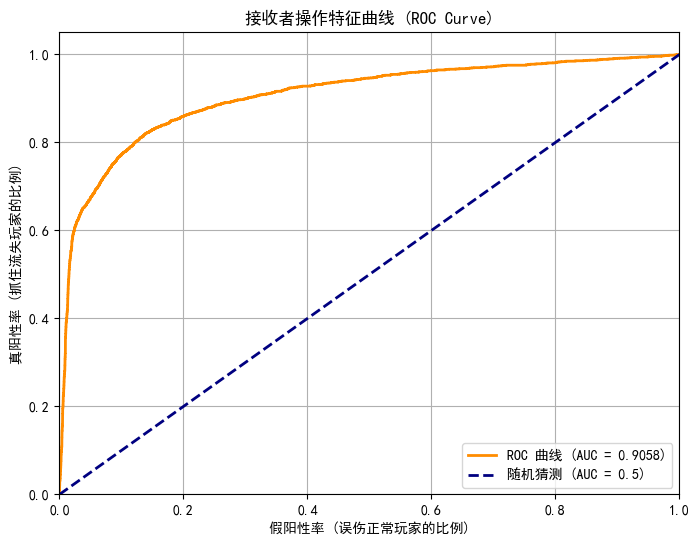

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测 (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (误伤正常玩家的比例)')
plt.ylabel('真阳性率 (抓住流失玩家的比例)')
plt.title('接收者操作特征曲线 (ROC Curve)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

此时可以看出模型的预测效果很好，接下来就可以使用模型预测随机玩家的流失概率了

### **建立随机玩家数据，用模型来预测流失风险**

##### 假设要预测玩家的信息为每周会话次数16次，平均会话时长为57min，玩家等级为61级，已解锁成就数量为22个

In [64]:
predict_data = pd.DataFrame({'const':[1],'SessionsPerWeek':[16],'AvgSessionDurationMinutes':[57],
                             'PlayerLevel':[61],'AchievementsUnlocked':[22]})
predict_data

,const,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
0,1,16,57,61,22


调用最终预测模型来预测结果

In [65]:
player_lose_probability = final_model.predict(predict_data)
player_lose_probability

0    0.030877
dtype: float64

##### **预测结果显示该玩家的流失概率为3.08%**